In [1]:
from retrieval import retrieve_intents, get_candidate_chunks, retrieve_chunks, rerank_chunks

d:\INQYST\Version 3\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 105/105 [00:00<00:00, 1221.93it/s]


In [2]:
from typing import TypedDict

class ChatState(TypedDict):
    question: str
    chat_history: list
    retrieved_intents: list
    finalized_intents: list
    intent_confidence: float
    handoff_required: bool
    retrieved_chunks: list
    context: str
    answer: str

In [3]:
from dotenv import load_dotenv
import os

load_dotenv()

GROQ_API_KEY = os.getenv(
    "GROQ_API_KEY"
)

In [4]:
from groq import Groq

groq_client = Groq(
    api_key=GROQ_API_KEY
)

# from google import genai


# gemini_client = genai.Client(
#     api_key=os.getenv("GEMINI_API_KEY")
# )

GROQ_MODEL = "llama-3.3-70b-versatile"
# GEMINI_MODEL = "gemini-2.5-flash"


### Intent Retrieval

In [5]:
def intent_node(state):

    results = retrieve_intents(
        state["question"],
        k=5
    )

    state["retrieved_intents"] = results
    state["intent_confidence"] = results[0]["score"]

    return state

### Intent Finalization

In [6]:
import json

def intent_finalization_node(state):
    query = state["question"]
    retrieved_intents = state["retrieved_intents"]

    intent_options = []
    for item in retrieved_intents:
        intent = item["intent"]
        intent_options.append(
            {
                "intent": intent["intent"],
                "description": intent["description"],
                "sample_queries": intent["sample_queries"],
                "retrieval_score": item["score"]
            }
        )

    messages = [
        {
            "role": "system",
            "content": (
                "You are an intent selection assistant. Select the 1 or 2 best "
                "matching intents for the user's question from the provided "
                "candidate intents. Use the intent descriptions and sample "
                "queries. Return only valid JSON with this schema: "
                "{\"selected_intents\": [\"intent_name\"], \"reason\": \"short reason\"}."
            )
        },
        {
            "role": "user",
            "content": json.dumps(
                {
                    "question": query,
                    "candidate_intents": intent_options
                },
                indent=2
            )
        }
    ]

    response = groq_client.chat.completions.create(
        model=GROQ_MODEL,
        messages=messages,
        temperature=0,
        response_format={"type": "json_object"}
    )

    try:
        result = json.loads(
            response.choices[0].message.content
        )
        selected_names = result.get(
            "selected_intents",
            []
        )[:2]
    except json.JSONDecodeError:
        selected_names = []

    selected = [
        item
        for item in retrieved_intents
        if item["intent"]["intent"] in selected_names
    ]

    if not selected:
        selected = retrieved_intents[:1]

    state["finalized_intents"] = selected
    state["intent_confidence"] = selected[0]["score"]
    return state

# import json

# def intent_finalization_node(state):

#     query = state["question"]
#     retrieved_intents = state["retrieved_intents"]

#     intent_options = []

#     for item in retrieved_intents:

#         intent = item["intent"]

#         intent_options.append(
#             {
#                 "intent": intent["intent"],
#                 "description": intent["description"],
#                 "sample_queries": intent["sample_queries"],
#                 "retrieval_score": item["score"]
#             }
#         )

#     prompt = f"""
# You are an intent selection assistant.

# Select the 1 or 2 best matching intents for the user's question.

# Use:
# - intent descriptions
# - sample queries
# - retrieval scores

# Return ONLY valid JSON.

# Schema:
# {{
#     "selected_intents": ["intent_name"],
#     "reason": "short reason"
# }}

# Question:
# {query}

# Candidate Intents:
# {json.dumps(intent_options, indent=2)}
# """

#     response = gemini_client.models.generate_content(
#         model="gemini-2.5-flash",
#         contents=prompt
#     )

#     response_text = response.text

#     try:

#         result = json.loads(response_text)

#         selected_names = result.get(
#             "selected_intents",
#             []
#         )[:2]

#     except Exception:

#         print(
#             "Intent Finalization Parse Error:"
#         )

#         print(response_text)

#         selected_names = []

#     selected = [

#         item

#         for item in retrieved_intents

#         if item["intent"]["intent"]
#         in selected_names
#     ]

#     if not selected:

#         selected = retrieved_intents[:1]

#     state["finalized_intents"] = selected

#     state["intent_confidence"] = (
#         selected[0]["score"]
#         if selected
#         else 0
#     )

#     return state

### Human-Agent Router

In [7]:
def route_after_intent(state):

    intents = state.get(
        "finalized_intents",
        state["retrieved_intents"]
    )

    if not intents:
        return "human_handoff"

    top_score = intents[0]["score"]

    if top_score < 0.45:
        return "human_handoff"

    return "chunk_retrieval"

### Human Handoff

In [8]:
def human_handoff_node(state):

    state["answer"] = (
        "I couldn't confidently determine the "
        "best resolution for your request. "
        "Please wait while we connect your "
        "request to our support team."
    )

    state["handoff_required"] = True
    return state

### Chunk Retrieval

In [9]:
def chunk_node(state):
    query = state["question"]
    candidate_ids = get_candidate_chunks(
        state.get(
            "finalized_intents",
            state["retrieved_intents"]
        )
    )
    chunks = retrieve_chunks(
        query,
        candidate_ids,
        top_k=15
    )
    reranked_chunks = rerank_chunks(
        query,
        chunks,
        top_k=5
    )
    state["retrieved_chunks"] = reranked_chunks
    return state

In [10]:
def route_after_chunk_retrieval(state):
    chunks = state.get(
        "retrieved_chunks",
        []
    )

    if not chunks:
        return "human_handoff"

    (
        (chunk, retrieval_score),
        rerank_score
    ) = chunks[0]

    if rerank_score < -5:
        return "human_handoff"
    return "context_builder"

### Context Build

In [11]:
def context_node(state):
    contexts = []

    for (
        (chunk, retrieval_score),
        rerank_score
    ) in state["retrieved_chunks"]:

        contexts.append(
            chunk["chunk"]
        )

    state["context"] = "\n\n".join(
        contexts
    )
    return state

### Response Generation

In [12]:
def generation_node(state):
    history = state["chat_history"]
    context = state["context"]
    query = state["question"]

    messages = [
        {
            "role": "system",
            "content": (
                "You are a helpful support assistant. Answer the user's question "
                "using only the provided context. If the context does not contain "
                "enough information and if you are not confident enough to form a "
                "relevant answer, just say that you do not have enough information "
                "to help the user and a human agent will be in touch with the user. "
                "Some previous assistant messages may include handoff status notes; "
                "use those notes to avoid treating escalated issues as resolved."
            ),
        }
    ]

    for h in history:
        content = h["content"]
        if h["role"] == "assistant" and h.get("handoff_required") is True:
            content = (
                "[Previous assistant response was escalated to a human support agent]\n"
                + content
            )

        messages.append(
            {
                "role": h["role"],
                "content": content,
            }
        )

    messages.append(
        {
            "role": "user",
            "content": (
                f"Context:\n{context}\n\n"
                f"Question:\n{query}"
            ),
        }
    )

    response = groq_client.chat.completions.create(
        model=GROQ_MODEL,
        messages=messages,
        temperature=0.0,
    )

    state["handoff_required"] = False
    state["answer"] = response.choices[0].message.content
    return state

# def generation_node(state):

#     history = state["chat_history"]
#     context = state["context"]
#     query = state["question"]

#     system_prompt = (
#         "You are a helpful support assistant. "
#         "Answer the user's question using only the provided context. "
#         "If the context does not contain enough information, say that "
#         "you do not have enough information and that a human agent will "
#         "be in touch with the user to solve their issue. "
#         "You do not have to explicitly mention that the context does not "
#         "provide enough information. "
#         "Some previous assistant messages may include handoff status notes; "
#         "use those notes to avoid treating escalated issues as resolved."
#     )

#     conversation = []

#     for h in history:

#         content = h["content"]

#         if (
#             h["role"] == "assistant"
#             and h.get("handoff_required") is True
#         ):
#             content = (
#                 "[Previous assistant response was escalated "
#                 "to a human support agent]\n"
#                 + content
#             )

#         conversation.append(
#             f"{h['role'].upper()}: {content}"
#         )

#     prompt = f"""
# {system_prompt}

# Conversation History:
# {chr(10).join(conversation)}

# Context:
# {context}

# Current User Question:
# {query}

# Answer:
# """

#     response = gemini_client.models.generate_content(
#         model=GEMINI_MODEL,
#         contents=prompt
#     )

#     state["handoff_required"] = False
#     state["answer"] = response.text

#     return state

### Memory Update

In [13]:
def memory_node(state):
    state["chat_history"].append(
        {
            "role":"user",
            "content":state["question"]
        }
    )
    state["chat_history"].append(
        {
            "role":"assistant",
            "content":state["answer"],
            "handoff_required": state.get("handoff_required",False)
        }
    )
    return state

### Graph Build

In [14]:
from langgraph.graph import StateGraph

graph = StateGraph(ChatState)

graph.add_node(
    "intent_retrieval/intent_classifier",
    intent_node
)
graph.add_node(
    "intent_finalization",
    intent_finalization_node
)
graph.add_node(
    "human_handoff",
    human_handoff_node
)
graph.add_node(
    "chunk_retrieval",
    chunk_node
)
graph.add_node(
    "context_builder",
    context_node
)
graph.add_node(
    "generation",
    generation_node
)
graph.add_node(
    "memory_update",
    memory_node
)

graph.set_entry_point(
    "intent_retrieval/intent_classifier"
)
graph.add_edge(
    "intent_retrieval/intent_classifier",
    "intent_finalization"
)
graph.add_conditional_edges(
    "intent_finalization",
    route_after_intent,
    {
        "chunk_retrieval": "chunk_retrieval",
        "human_handoff": "human_handoff",
    },
)
graph.add_edge(
    "human_handoff",
    "memory_update"
)


graph.add_conditional_edges(
"chunk_retrieval",
route_after_chunk_retrieval,
{
    "context_builder": "context_builder",
    "human_handoff": "human_handoff",
},)


graph.add_edge(
    "context_builder",
    "generation"
)
graph.add_edge(
    "generation",
    "memory_update"
)


app = graph.compile()

In [15]:
print(app.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	intent_retrieval\2fintent_classifier(intent_retrieval/intent_classifier)
	intent_finalization(intent_finalization)
	human_handoff(human_handoff)
	chunk_retrieval(chunk_retrieval)
	context_builder(context_builder)
	generation(generation)
	memory_update(memory_update)
	__end__([<p>__end__</p>]):::last
	__start__ --> intent_retrieval\2fintent_classifier;
	chunk_retrieval -.-> context_builder;
	chunk_retrieval -.-> human_handoff;
	context_builder --> generation;
	generation --> memory_update;
	human_handoff --> memory_update;
	intent_finalization -.-> chunk_retrieval;
	intent_finalization -.-> human_handoff;
	intent_retrieval\2fintent_classifier --> intent_finalization;
	memory_update --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



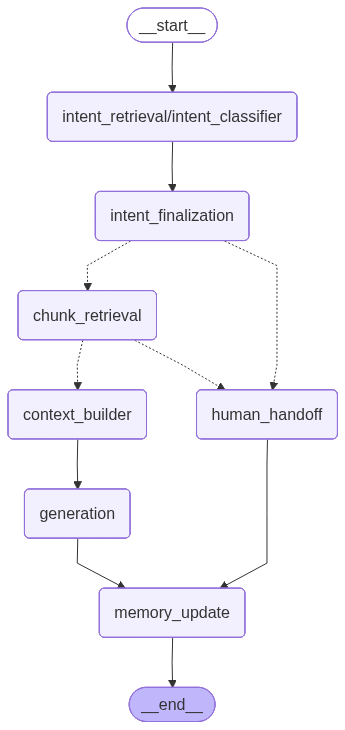

In [16]:
from IPython.display import Image, display

display(
    Image(
        app.get_graph().draw_mermaid_png()
    )
)

In [17]:
import streamlit as st
def make_initial_state(question):
    return {
        "question": question,
        "chat_history": st.session_state.chat_history,
        "retrieved_intents": [],
        "finalized_intents": [],
        "intent_confidence": 0.0,
        "handoff_required": False,
        "retrieved_chunks": [],
        "context": "",
        "answer": "",
    }

In [18]:
import json
import pandas as pd

with open(
    "data/langgraph_evaluation_dataset.json",
    "r"
) as f:
    eval_data = json.load(f)

In [19]:
st.set_page_config(
    page_title="LangGraph RAG Bot",
    page_icon="",
    layout="centered",
)

st.title("LangGraph RAG Bot")

if "chat_history" not in st.session_state:
    st.session_state.chat_history = []

if not os.getenv("GROQ_API_KEY"):
    st.error("GROQ_API_KEY is missing. Add it to your .env file before chatting.")
    st.stop()

with st.sidebar:
    st.caption("Memory is kept only for this Streamlit session.")
    if st.button("Reset conversation", use_container_width=True):
        st.session_state.chat_history = []
        st.rerun()

for message in st.session_state.chat_history:
    with st.chat_message(message["role"]):
        st.markdown(message["content"])
        if message["role"] == "assistant" and message.get("handoff_required"):
            st.caption("Human handoff requested")

2026-06-23 11:23:39.523 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-23 11:23:39.524 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-23 11:23:40.403 
  command:

    streamlit run d:\INQYST\Version 3\venv\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-06-23 11:23:40.403 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-23 11:23:40.408 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-23 11:23:40.410 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-23 11:23:40.412 Session state does not function when running a script without `streamlit run`
2026-0

In [20]:
results = []

for test in eval_data["intent_evaluation_queries"][33:]:

    query = test["query"]

    result = app.invoke(
        make_initial_state(query)
    )

    retrieved_intents = [item["intent"]["intent"]for item in result.get(
        "retrieved_intents",[])]
    
    predicted_intents = [item["intent"]["intent"]for item in result.get(
        "finalized_intents",[])]

    retrieved_chunk_ids = []
    if result["retrieved_chunks"]:
        retrieved_chunk_ids = [
            item[0][0]["chunk_id"]
            for item in result["retrieved_chunks"]
        ]

    retrieval_scores = []
    if result["retrieved_chunks"]:
        retrieval_scores = [float(item[0][1])
        for item in result["retrieved_chunks"]]


    rerank_scores = []
    if result["retrieved_chunks"]:
        rerank_scores = [float(item[1])
        for item in result["retrieved_chunks"]]
    
    bot_answer = result.get(
    "answer",
    "")

    results.append(
        {
            "query": query,
            
            "bot_answer":
            bot_answer,

            # "expected_intent":
            #     test["expected_intent"],
            
            "retrieved_intents":
                retrieved_intents,

            "predicted_intent":
                predicted_intents,

            # "intent_correct":
            #     test["expected_intent"] in predicted_intents,

            # "expected_chunk":
            #     test["expected_chunk"],

            "predicted_chunks":
                retrieved_chunk_ids,

            # "chunk_correct":
            #     test["expected_chunk"] in retrieved_chunk_ids,

            "rerank_scores":
                rerank_scores,
                
            "retrieval_scores":
                retrieval_scores
        }
    )

2026-06-23 11:23:40.465 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-23 11:23:43.495 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-23 11:23:49.395 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-23 11:23:55.183 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-23 11:23:58.678 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-23 11:24:02.834 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-23 11:24:07.595 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-23 11:24:11.521 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

InternalServerError: Error code: 503 - {'error': {'message': 'llama-3.3-70b-versatile is currently over capacity. Please try again and back off exponentially. Visit https://groqstatus.com to see if there is an active incident.', 'type': 'internal_server_error'}}

In [21]:
df = pd.DataFrame(results)
# df = pd.read_csv('data/final_results.csv')
# print(
#     f"Intent Accuracy: "
#     f"{df['intent_correct'].mean()*100:.2f}%"
# )

# print(
#     f"Chunk Accuracy: "
#     f"{df['chunk_correct'].mean()*100:.2f}%"
# )

In [22]:
df.head()

,query,bot_answer,retrieved_intents,predicted_intent,predicted_chunks,rerank_scores,retrieval_scores
0,manage profile settings,I couldn't confidently determine the best reso...,"[manage_profile_settings, manage_account_setti...",[manage_profile_settings],"[what_are_shopping_profiles_001, add_a_shoppin...","[-7.415574550628662, -8.850835800170898, -9.88...","[0.6908020973205566, 0.6802319288253784, 0.612..."
1,"I have a question about shopping profiles, mob...","To address your questions, I'll break down the...","[manage_profile_settings, manage_account_setti...",[manage_profile_settings],"[what_are_shopping_profiles_001, add_a_shoppin...","[-2.214125633239746, -4.833869934082031, -4.92...","[0.7348282337188721, 0.7029454112052917, 0.711..."
2,Can you help me with manage account settings?,"To manage your account settings, you can follo...","[manage_account_settings, manage_profile_setti...",[manage_account_settings],"[change_your_account_settings_001, manage_a_mu...","[-1.1918690204620361, -3.0011537075042725, -7....","[0.7671505808830261, 0.7208189964294434, 0.674..."
3,I need assistance regarding manage account set...,"To manage your account settings, you can refer...","[manage_account_settings, manage_profile_setti...",[manage_account_settings],"[change_your_account_settings_001, manage_a_mu...","[-3.5710275173187256, -5.305171966552734, -8.8...","[0.764009952545166, 0.7291958332061768, 0.6687..."
4,How does Amazon handle manage account settings?,Amazon provides several ways to manage account...,"[manage_account_settings, manage_profile_setti...",[manage_account_settings],[manage_thirdparty_apps_and_services_with_data...,"[0.2897999882698059, -4.335416793823242, -4.47...","[0.752913773059845, 0.7038500905036926, 0.6261..."


In [23]:
df.to_csv('data/latest_evaluation_2.csv')

In [24]:
df.shape

(21, 7)

In [ ]:
import json
import pandas as pd

with open(
    "data/intents_queries.json",
    "r",
    encoding="utf-8"
) as f:
    intents = json.load(f)

rows = []

for intent in intents:

    intent_name = intent["intent"]

    reference_chunk = (
        intent["source_chunks"][0]
        if intent["source_chunks"]
        else ""
    )

    for query in intent["sample_queries"][:5]:

        rows.append(
            {
                "query": query,
                "reference_chunk_id": reference_chunk,
                "intent_label": intent_name
            }
        )

df = pd.DataFrame(rows)

df.to_csv(
    "intent_evaluation_queries.csv",
    index=False
)

print(
    f"Saved {len(df)} queries"
)

## Evaluation Summary

The final evaluation was conducted on **28 intent-based queries** and **10 human handoff scenarios** to assess the performance of the complete LangGraph RAG pipeline, including Intent Retrieval, Intent Finalization, Chunk Retrieval, Reranking, Response Generation, and Human Handoff Routing.

### Overall Performance

| Metric | Score |
|----------|----------|
| Intent Accuracy | 96.4% (27/28) |
| Chunk Recall@5 | 92.9% (26/28) |

### Key Observations

#### Intent Retrieval Performance
- Intent retrieval performed strongly, achieving **96.4% accuracy**.
- Only one query was routed to an unexpected intent:
  - *"My package says delivered but I can't find it anywhere."*
- The failure appears to be caused by intent/chunk categorization rather than retrieval quality.

#### Chunk Retrieval Performance
- The correct chunk was retrieved within the Top-5 results for **92.9%** of evaluation queries.
- Only two chunk retrieval failures were observed:
  1. Missing delivered package scenario.
  2. Scam/payment verification email scenario.
- In both cases, semantically related chunks were retrieved, indicating a ranking/content optimization issue rather than a complete retrieval failure.

---

## Human Handoff Evaluation

### Current Handoff Logic
The handoff decision is currently based on:

```python
top_reranker_score < -5
```

### Results

| Metric | Result |
|----------|----------|
| Human Handoff Test Queries | 10 |
| Queries Actually Routed to Human | 5 |
| Queries Answered by Bot Instead | 5 |

### Observations

The current threshold is **too conservative**.

Several queries that should realistically require manual investigation were answered using available knowledge-base content because the top reranker score remained above the handoff threshold.

Examples include:

- Account compromise and unauthorized purchases
- Suspended account investigations
- Missing refunds after return completion
- Business account billing disputes
- Long-term subscription reimbursement requests

Although some generated responses advised contacting support, they were still processed as normal chatbot responses rather than being formally escalated.

---

## Major Failure Modes

### 1. Intent–Chunk Mapping Issues
Some chunks are assigned to intents that do not closely match real user phrasing.

Example:
 - The query *"My package says delivered but I can't find it anywhere"* was mapped to a delivery-related intent, while the expected chunk was categorized under `other_query`.
- `missing_package_delivered_001` is categorized separately while users naturally phrase it as a delivery/tracking issue.

### 2. Chunk Content Limitations
Query: 'If your package shows as delivered but you haven't received it, you can check the "Find a missing package that shows as delivered" page for assistance. Additionally, you can also check if a delivery photo was taken by Amazon, which may show the location of your package or where it was delivered. You can find this photo in "Track your package" in Your Orders.'

- `missing_package_delivered_001` was the right chunk, we predicted ['track_package_003', 'track_package_004', 'photo_delivery_001', 'map_tracking_001', 'track_package_001'],

- chunk content: Follow these steps if tracking shows a package as delivered in Your Orders but you can't find it.

Certain chunks lack realistic customer terminology and alternative phrasings, reducing embedding quality and retrieval effectiveness.


### 3. Wrong query chunk mapping
Query: I received an email asking me to verify my Amazon payment details.

- `identifying_a_scam_001` was the right chunk we considered, we predicted ['scam_trends_002', 'scam_trends_004', 'scam_trends_005', 'avoiding_payment_scams_001', 'report_a_scam_001']

- `identifying_a_scam_001` - 'Learn to identify, prevent, and report scams.\n\nYou can visit the following Help pages for additional tips to identify a fake communication:\n\nHow to identify fake emails\n\nHow to identify fake text messages/SMS\n\nHow to identify fake phone calls\n\nHow to identify fake websites"'

- `scam_trends_002` - Order confirmation scams involve unexpected communications that often refer to an\nunauthorized purchase. Scammers ask you to act urgently to confirm or cancel the purchase.\nThey may try to convince you to provide payment details, install software, or purchase\ngift cards.\n\nIf you received unexpected correspondence regarding an order, verify your orders by\nlogging into your Amazon account. Only legitimate purchases will appear in your\norder history. You can also contact Customer Service for support."

- `scam_trends_004` - Membership fee scams claim that a membership fee is owed, or that there's an issue\nwith your membership. Scammers try to convince you to provide payment or bank account\ninformation to reinstate a membership. Amazon will never ask you to provide payment\ninformation for products or services over the phone. Visit the\nMessage Center on the Amazon website or mobile app to review authentic emails from Amazon. To verify\nyour\nPrime Membership or make payments, log in to Amazon, and under\n**Your Account** select\n**Prime Membership**.

- `scam_trends_005` - Account suspension/deletion scams claim your account will be suspended or deleted\nunless you take specific action. Actions may include selecting a fraudulent link or\nproviding information like payment details or login credentials, to 'verify your account'.\nAmazon never asks for your password or for sensitive personal information over the\nphone or on any external website. Don’t access any links or provide your information\nto anyone over the phone without authenticating the email or phone call. If you have\nquestions about your account status, visit the Amazon website or mobile app to view\nyour account details. Authentic emails from Amazon are logged in the\nMessage Center."

### 4. Ranking Ambiguity
- Multiple chunks occasionally receive very similar reranker scores
[1.503713607788086, 1.2529709339141846, 1.0711441040039062, -0.0160566046833992, -0.5698184967041016]


### 4. Human Handoff Threshold Too Strict
The largest weakness observed in the evaluation was the escalation logic.

Many complex investigation-type queries produced reranker scores between:

```text
-5 < score < 0
```

These were answered by the chatbot despite being scenarios that would normally require human review.
- Also we only considered top reranker score, [-3.3830127716064453, -5.550544261932373, -7.382736682891846, -8.559452056884766, -8.853439331054688], all other scores are less than -5

## Areas for Improvement

- Revisit intent-to-chunk mappings for ambiguous cases.
- Enrich chunk content with realistic customer language and synonyms.
- Increase sample queries per intent to strengthen intent embeddings.
- Continue monitoring Recall@5 alongside intent accuracy.
- Reevaluate the human handoff threshold:
  - A threshold of `-5` appears overly strict.
  - Consider experimenting with higher thresholds or combining reranker confidence with intent confidence and query complexity signals.

---

## Conclusion

The evaluation demonstrates that the core RAG pipeline is performing well:

- Intent retrieval is highly accurate (**96.4%**).
- Chunk retrieval is consistently strong (**92.9% Recall@5**).
- Most failures originate from chunk organization and ranking rather than workflow design.

The primary improvement area is **human escalation routing**. While retrieval quality is mature, the current handoff threshold allows several investigation-heavy and account-specific issues to be answered by the chatbot when they would be better handled by a human support agent. Future iterations should focus on refining escalation logic and knowledge-base coverage rather than making major architectural changes.